Pos cocok: 30 | train: 84,396 baris | submission: 21,780 baris
Arjowinangun - Pacitan: train=1428, prediksi=726
Babat: train=1412, prediksi=726
Badegan: train=1426, prediksi=726
Bengkelolor: train=1426, prediksi=726
Boboh Kali Lamong: train=1427, prediksi=726
Bojonegoro - Kali Kethek: train=1413, prediksi=726


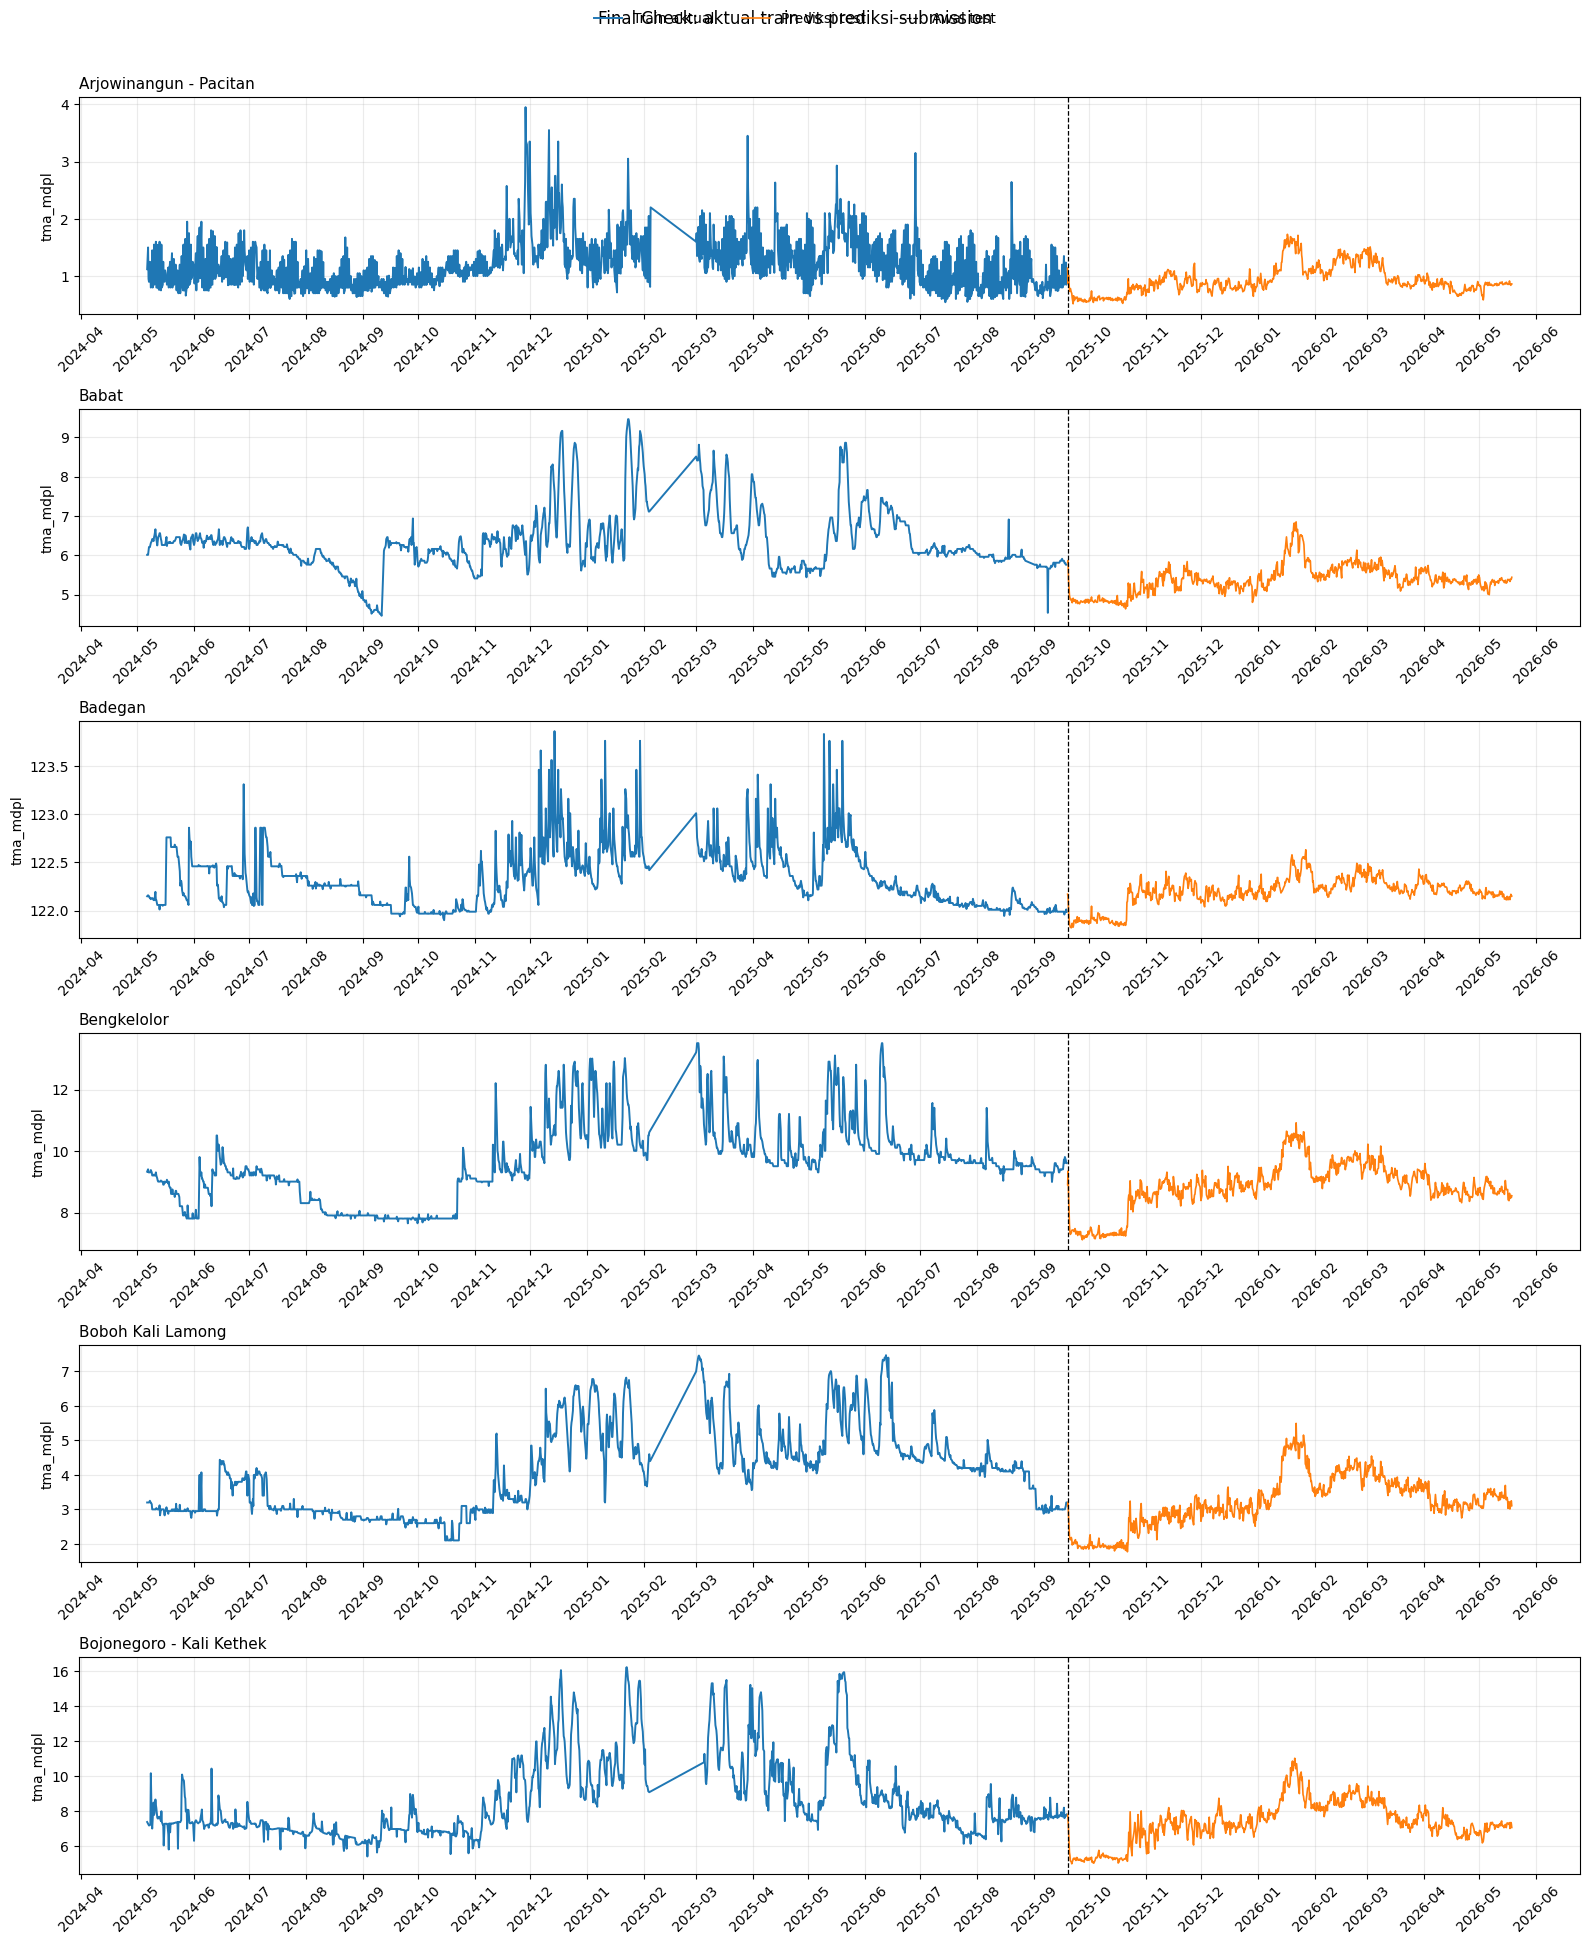

Brangkal: train=1426, prediksi=726
Cepu: train=1423, prediksi=726
Colo Weir: train=1428, prediksi=726
Floodway Bridge C: train=1426, prediksi=726
Gunungsari: train=1126, prediksi=726
Jarum: train=1425, prediksi=726


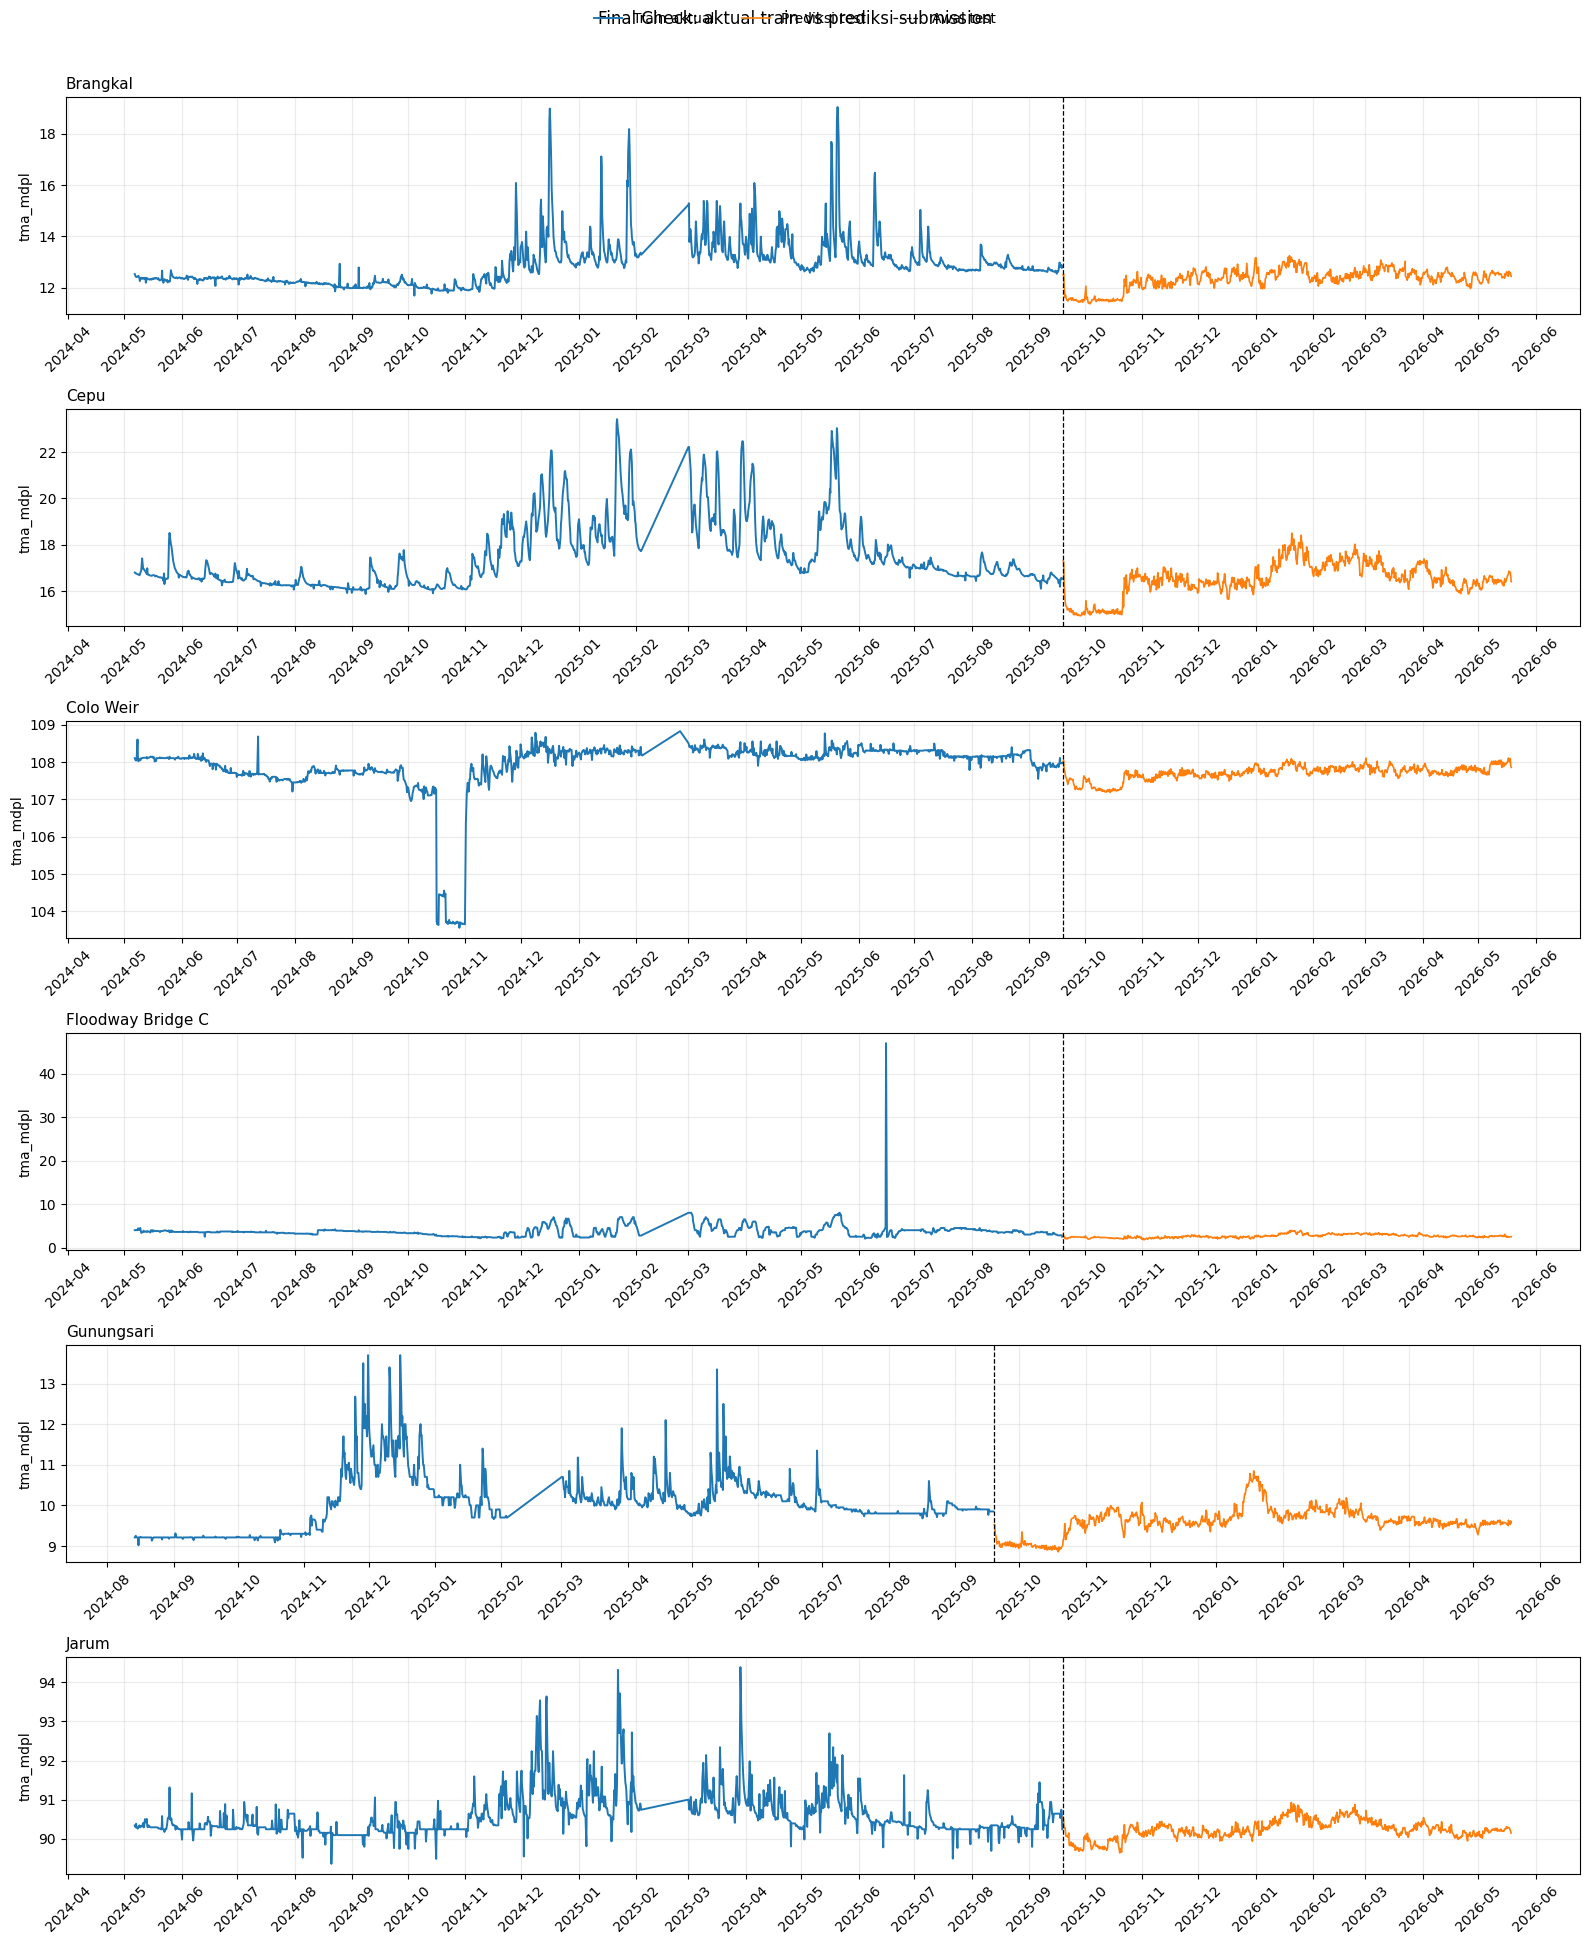

Jurug: train=1428, prediksi=726
Kajangan: train=1426, prediksi=726
Kali Anyar - Kreteg Abang: train=1426, prediksi=726
Kali Pepe - PTPN: train=1426, prediksi=726
Kali Pepe - Tugu Boto: train=1426, prediksi=726
Karanggeneng: train=1428, prediksi=726


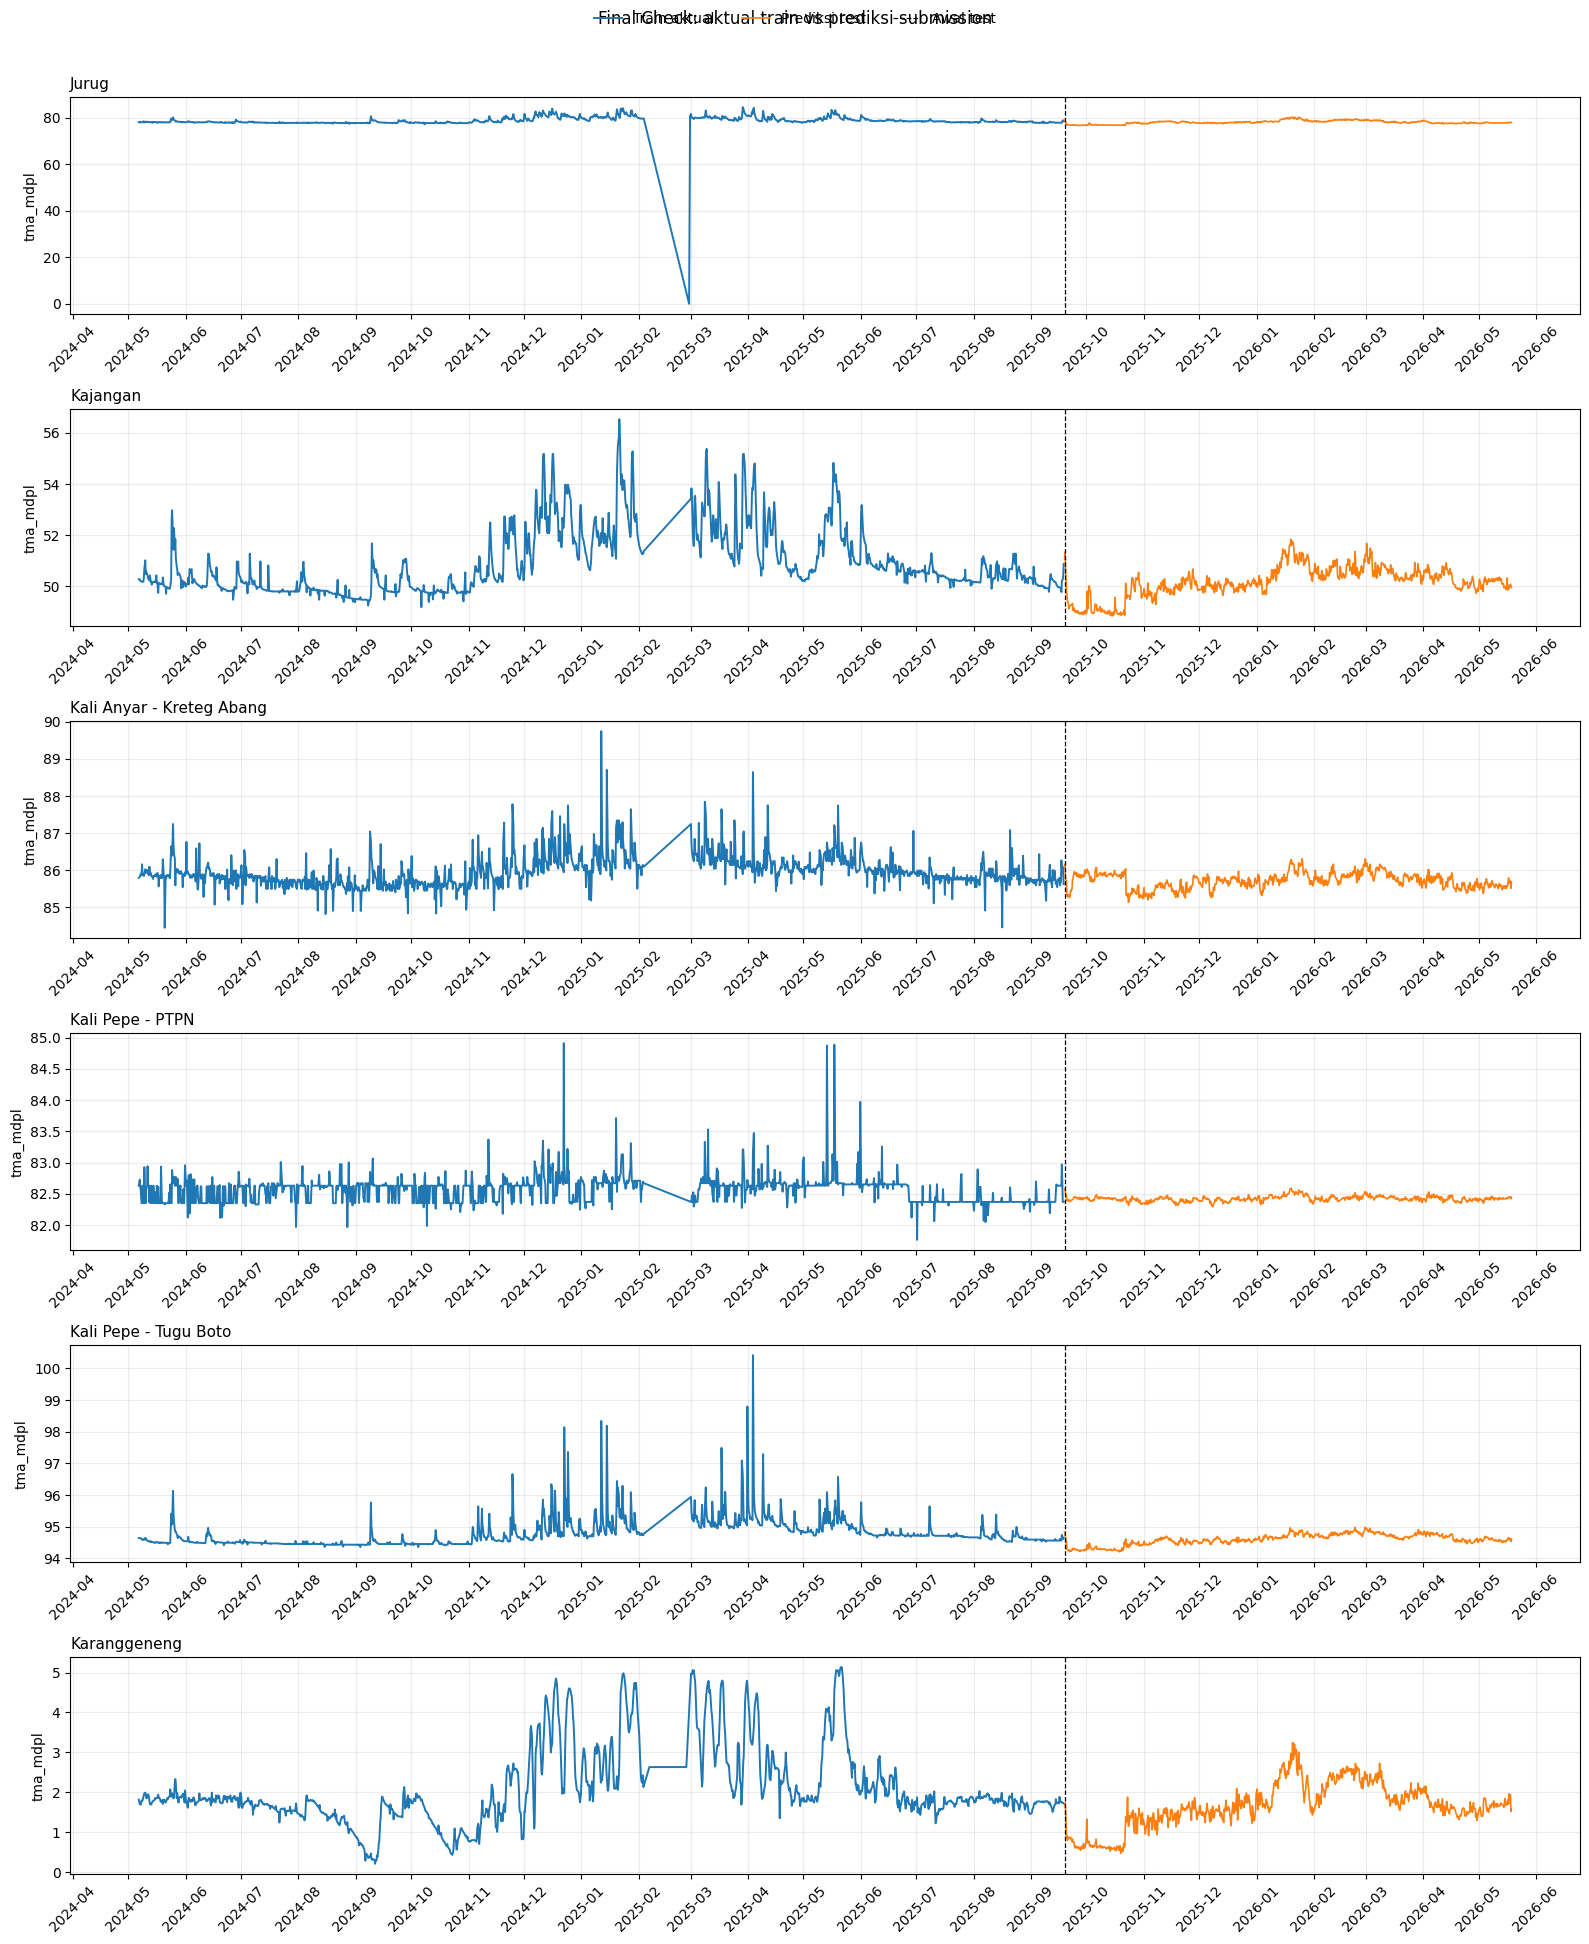

Karangnongko: train=1426, prediksi=726
Kedungupit: train=1426, prediksi=726
Ketonggo: train=1426, prediksi=726
Lorog: train=1426, prediksi=726
Napel: train=1426, prediksi=726
Ngadipiro: train=1426, prediksi=726


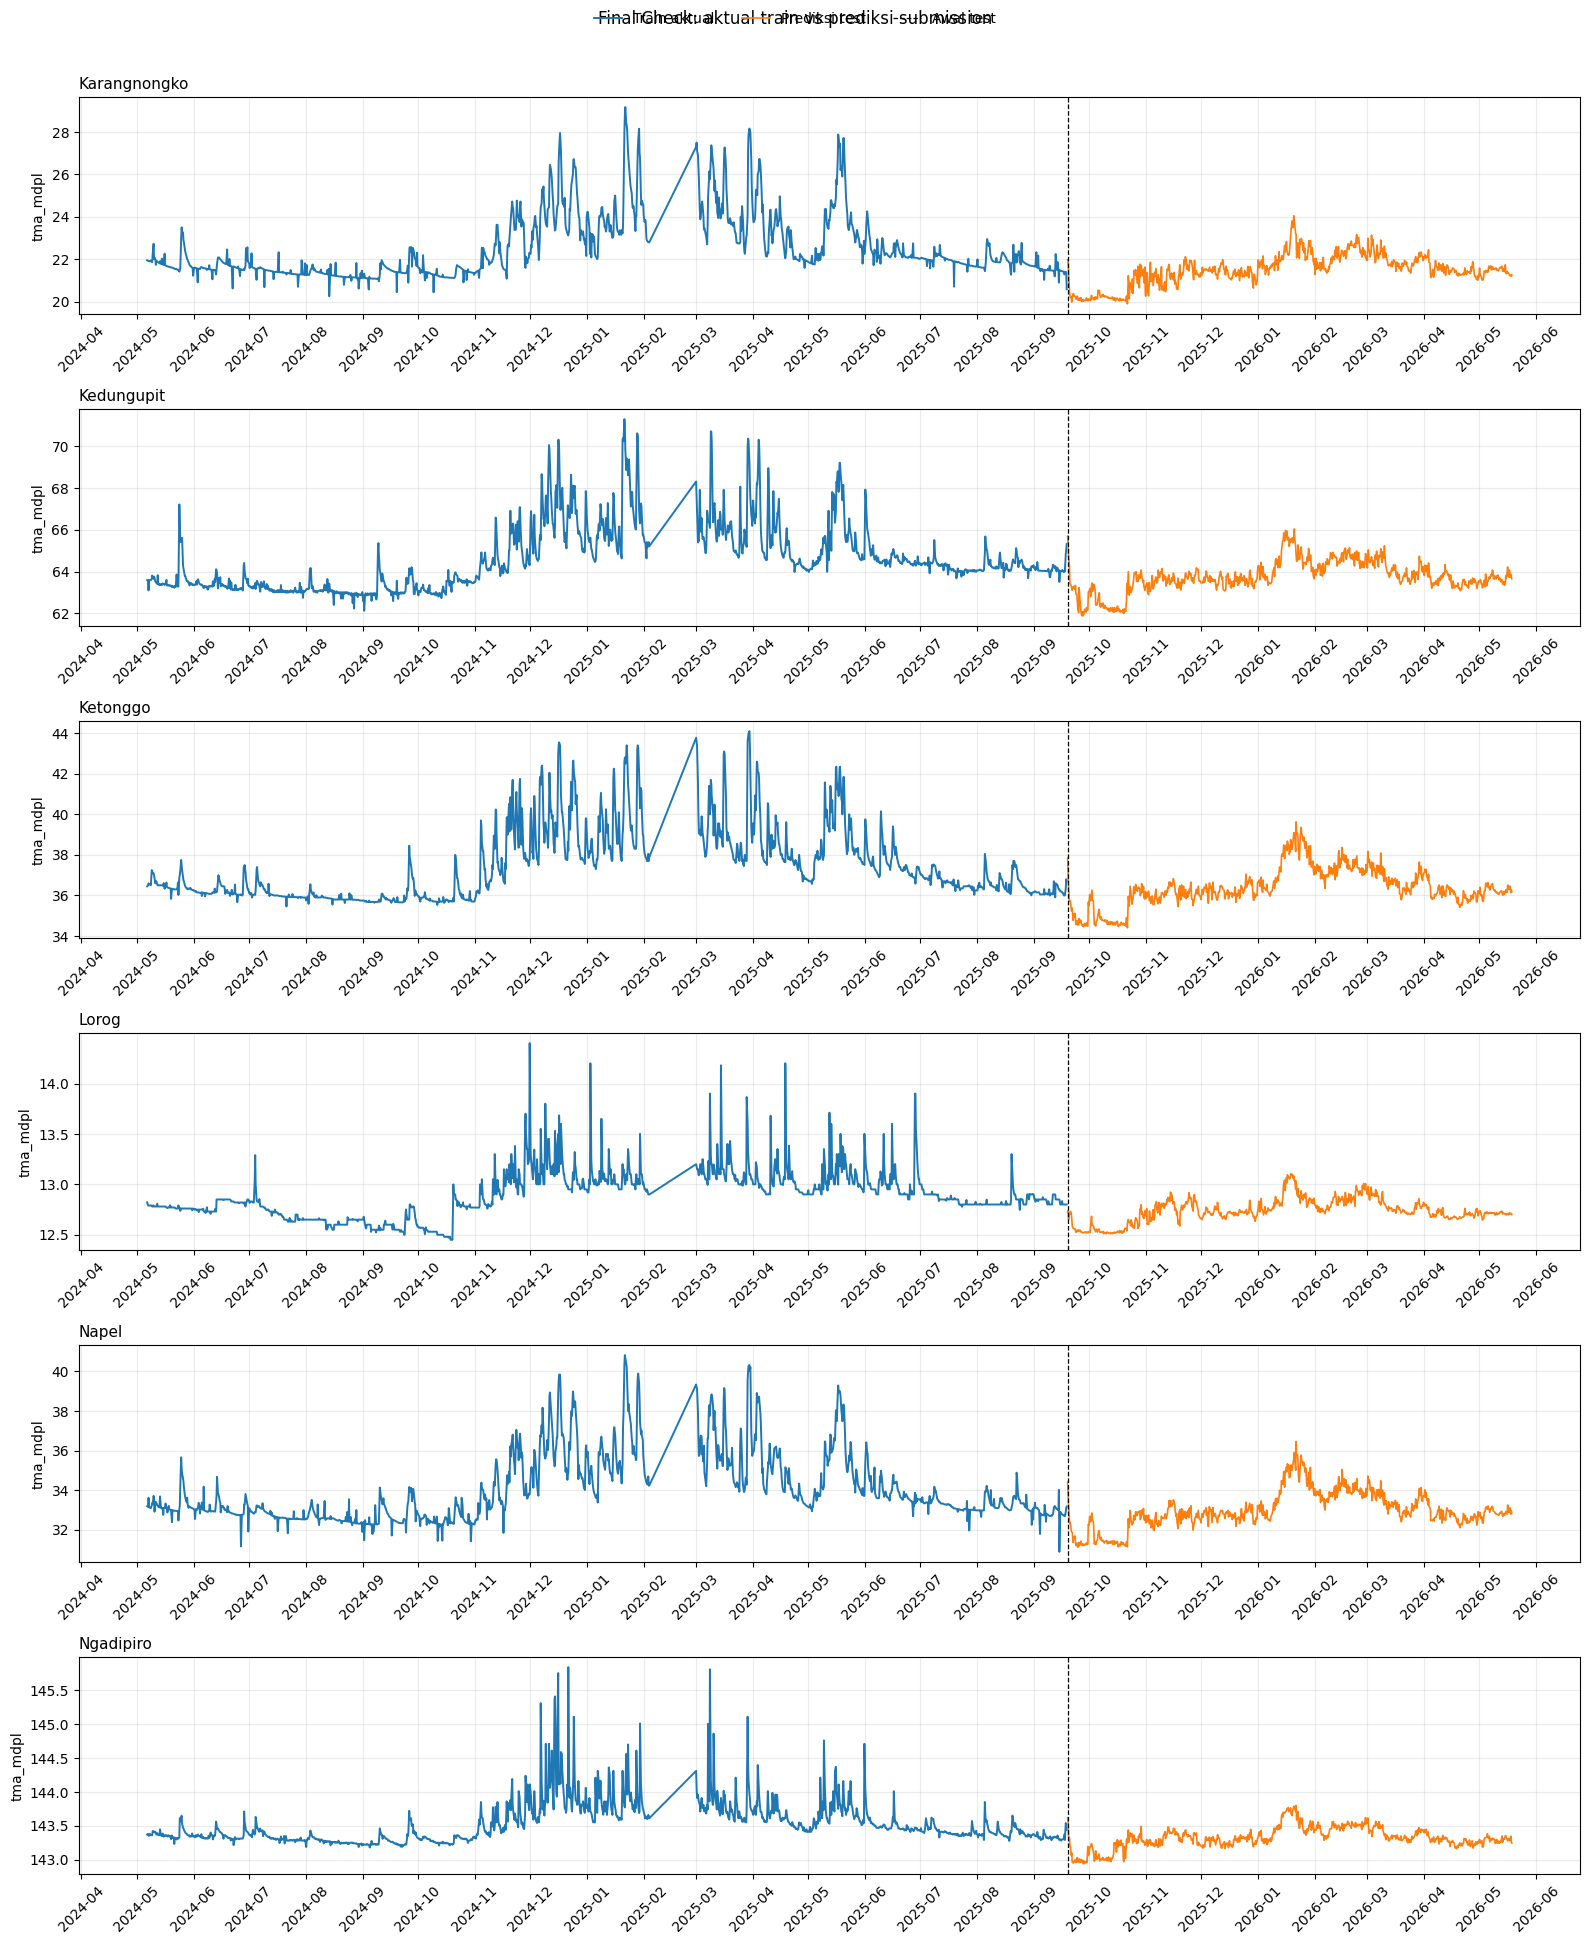

Ngrembang: train=1426, prediksi=726
Peren: train=1427, prediksi=726
Sekayu: train=1426, prediksi=726
Serenan: train=1426, prediksi=726
Sumberrejo: train=1404, prediksi=726
Wonogiri Dam: train=1426, prediksi=726


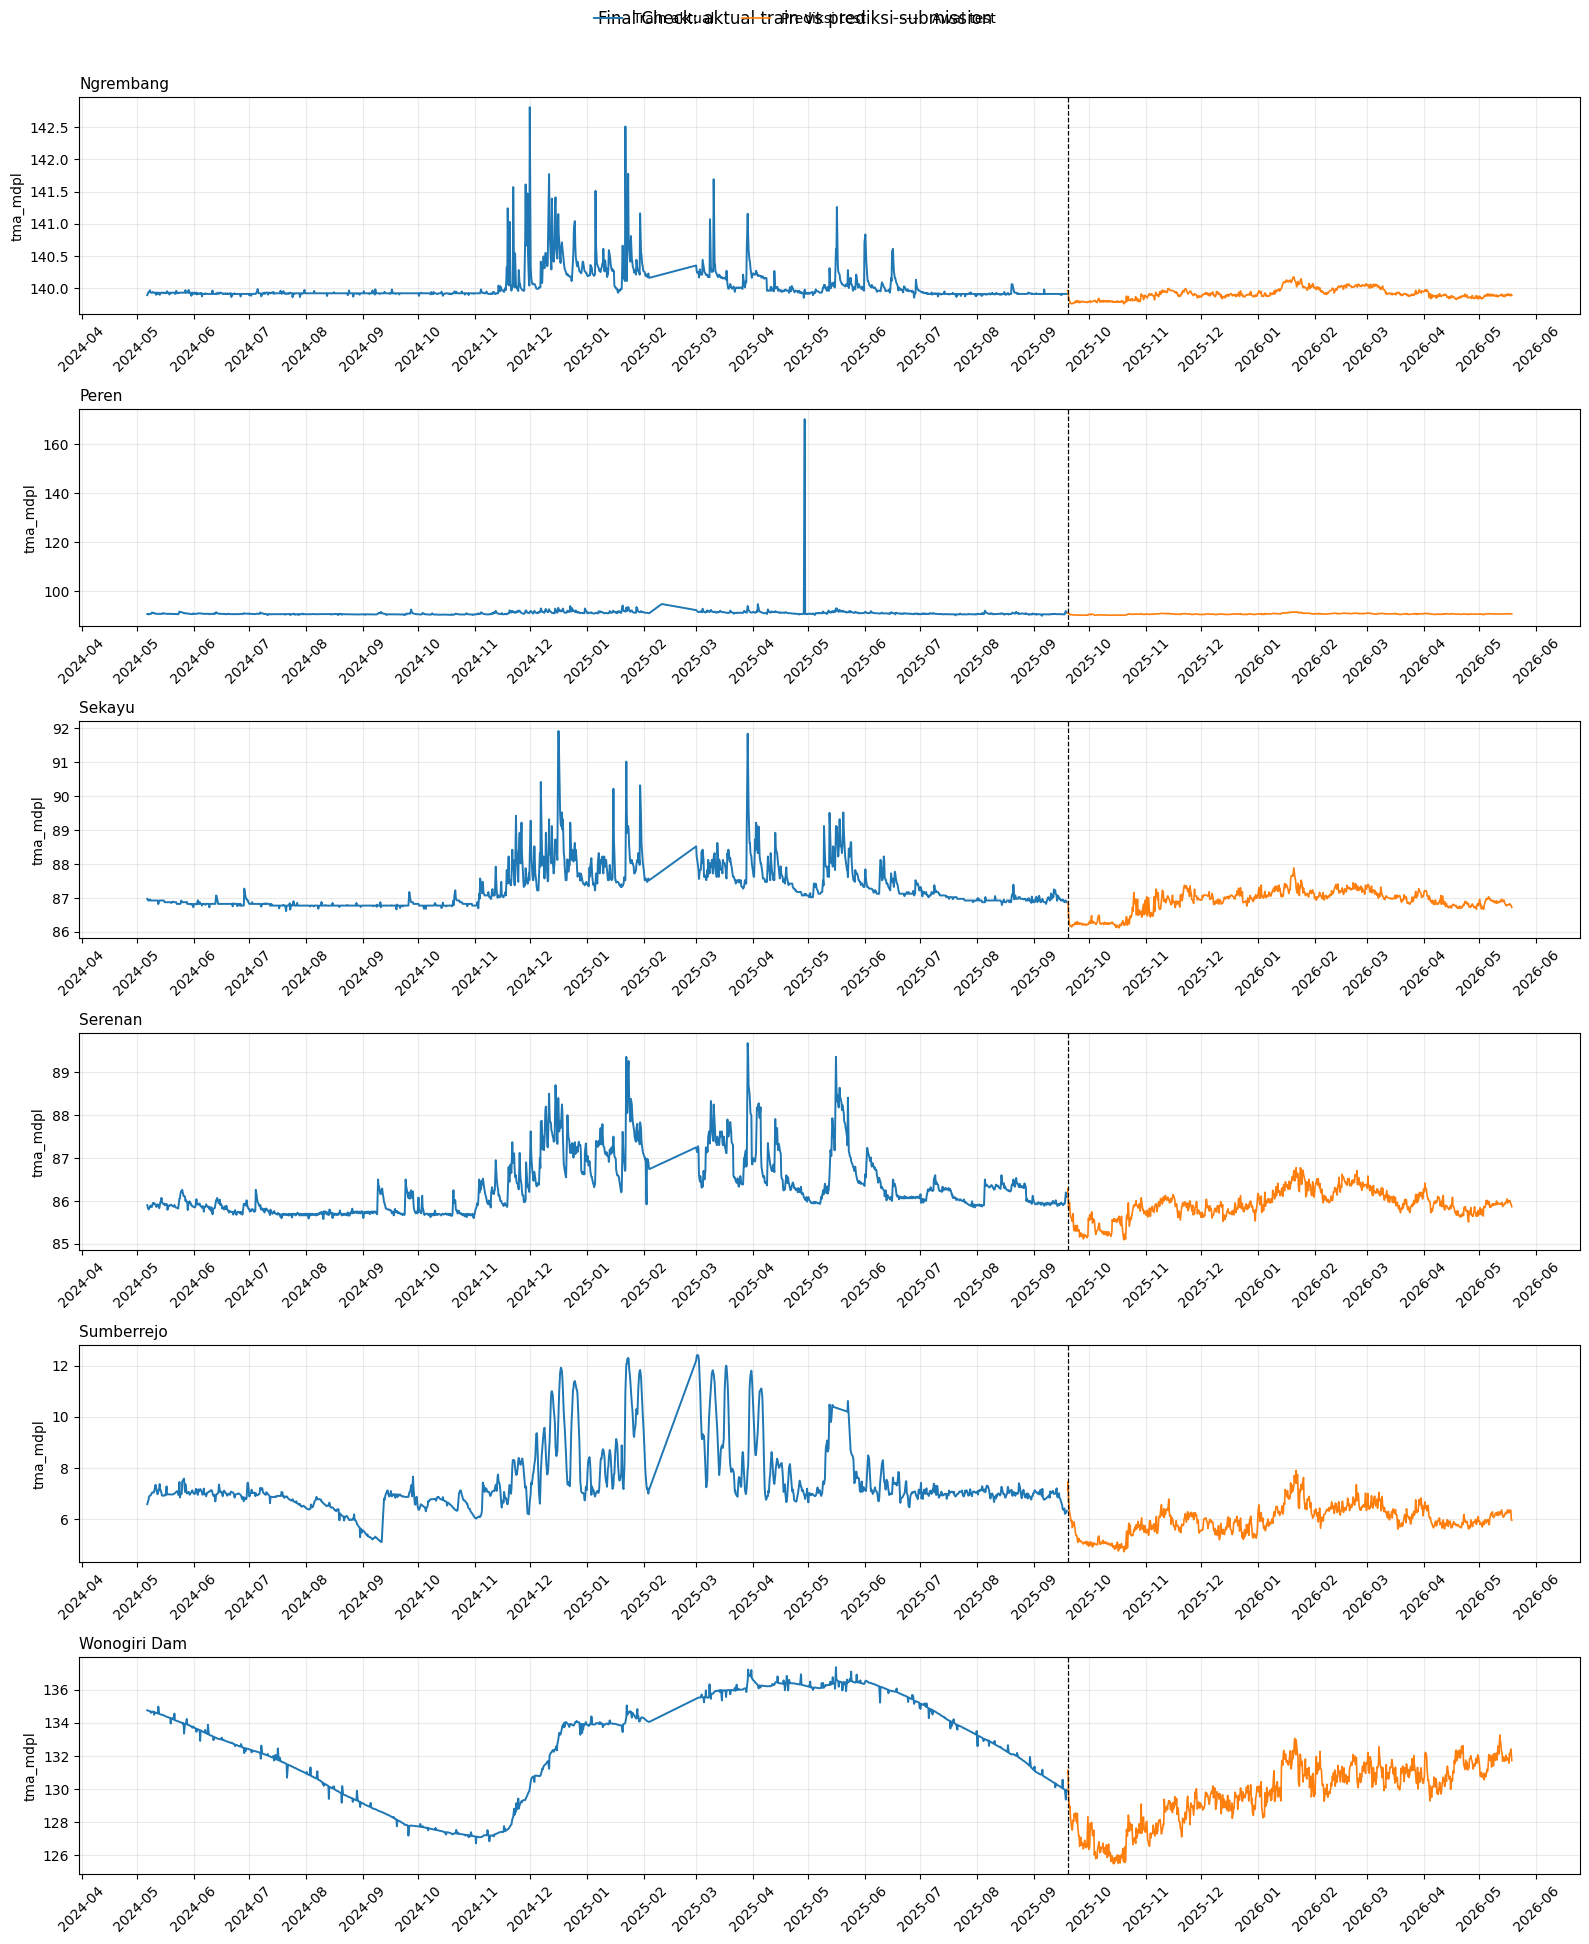

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
import matplotlib.dates as mdates

OUTPUT_PATH = "submission.csv"

train_check = pd.read_csv("train.csv")
submission_path = Path(OUTPUT_PATH)
if not submission_path.exists():
    raise FileNotFoundError(f"Submission tidak ditemukan: {submission_path}. Jalankan cell inferensi terlebih dahulu.")

submission_check = pd.read_csv(submission_path)
train_check["datetime"] = pd.to_datetime(train_check["datetime"])
submission_check["datetime"] = pd.to_datetime(submission_check["id"].str[:19])
submission_check["nama_pos"] = submission_check["id"].str[22:]

stations = sorted(set(train_check["nama_pos"]) & set(submission_check["nama_pos"]))
if not stations:
    raise ValueError("Tidak ada nama_pos yang cocok antara train.csv dan submission.csv.")

# Tampilkan enam pos per gambar agar garis tidak menjadi terlalu kecil/putih
# saat renderer notebook mengecilkan gambar yang sangat tinggi.
train_plot_start = train_check["datetime"].max() - pd.Timedelta(days=500)
stations_per_figure = 6
print(f"Pos cocok: {len(stations)} | train: {len(train_check):,} baris | submission: {len(submission_check):,} baris")

for first in range(0, len(stations), stations_per_figure):
    station_batch = stations[first:first + stations_per_figure]
    fig, axes = plt.subplots(len(station_batch), 1, figsize=(16, 3.2 * len(station_batch)), sharex=False)
    axes = np.atleast_1d(axes)

    for ax, station in zip(axes, station_batch):
        actual = train_check.loc[
            (train_check["nama_pos"] == station) & (train_check["datetime"] >= train_plot_start)
        ].sort_values("datetime")
        predicted = submission_check.loc[submission_check["nama_pos"] == station].sort_values("datetime")

        print(f"{station}: train={len(actual)}, prediksi={len(predicted)}")
        ax.plot(actual["datetime"], actual["tma_mdpl"], color="#1f77b4", lw=1.4, label="Train aktual")
        ax.plot(predicted["datetime"], predicted["tma_mdpl"], color="#ff7f0e", lw=1.2, label="Prediksi test")
        if not predicted.empty:
            ax.axvline(predicted["datetime"].min(), color="black", ls="--", lw=0.9, label="Awal test")
        ax.set_title(station, loc="left", fontsize=11)
        ax.set_ylabel("tma_mdpl")
        ax.grid(alpha=0.25)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis="x", rotation=45)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
    fig.suptitle("Final Check: aktual train vs prediksi submission", y=1.01)
    fig.tight_layout()
    plt.show()